In [1]:
import numpy as np
from scipy import misc  
import imageio                   # for loading image
np.random.seed(1)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13736\3390217771.py:2: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


In [2]:
# filename structure
path = 'unpadded/' # path to the database
ids = range(1, 16) # 15 persons
states = ['centerlight', 'glasses', 'happy', 'leftlight',
          'noglasses', 'normal', 'rightlight','sad',
          'sleepy', 'surprised', 'wink' ]
prefix = 'subject'
surfix = '.pgm'

In [3]:
# data dimension
h = 116 # hight
w = 98 # width
D = h * w
N = len(states)*15
K = 100

In [4]:
# collect all data
X = np.zeros((D, N))
cnt = 0
for person_id in range(1, 16):
    for state in states:
        fn = path + prefix + str(person_id).zfill(2) + '.' + state + surfix
        X[:, cnt] = imageio.imread(fn).reshape(D)
        cnt += 1


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13736\3287775218.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  X[:, cnt] = imageio.imread(fn).reshape(D)


In [5]:
# Doing PCA, note that each row is a datapoint
from sklearn.decomposition import PCA
pca = PCA(n_components=K) # K = 100
pca.fit(X.T)


,n_components,100
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [6]:
# projection matrix
U = pca.components_.T

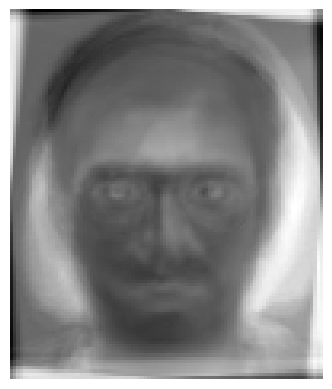

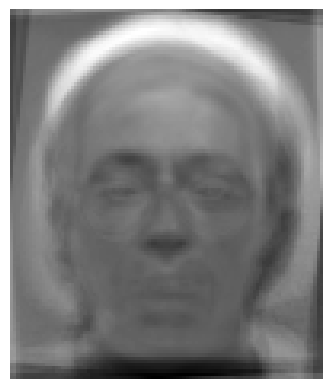

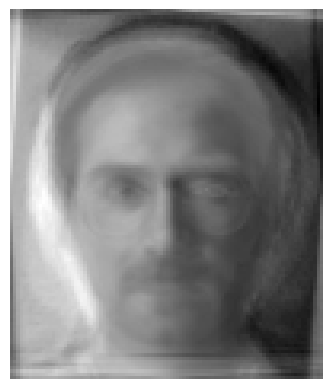

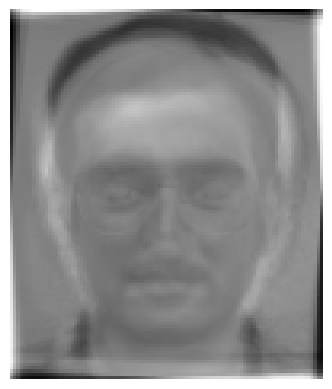

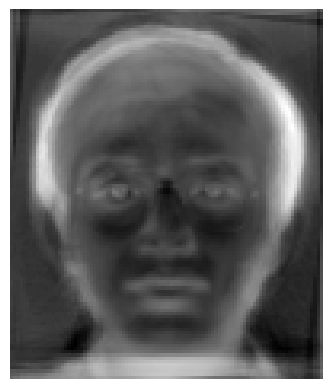

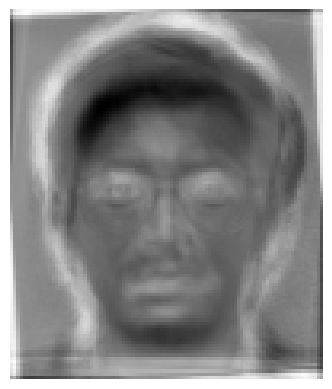

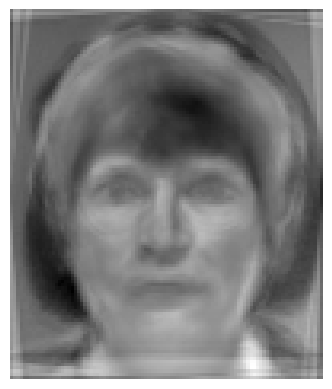

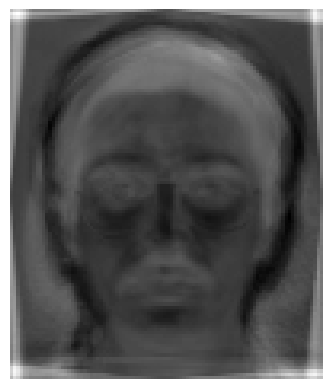

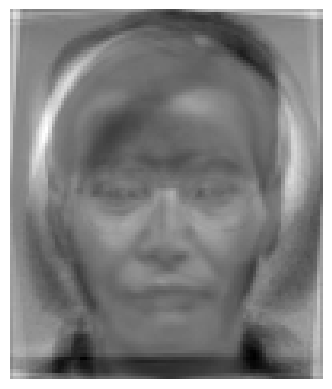

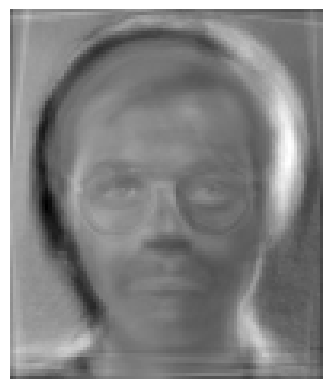

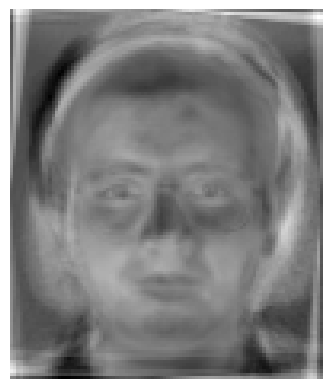

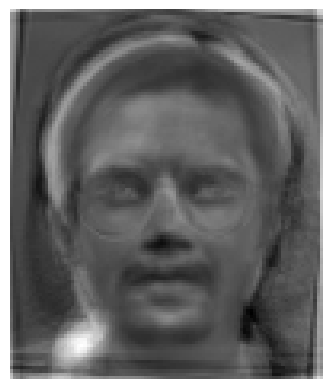

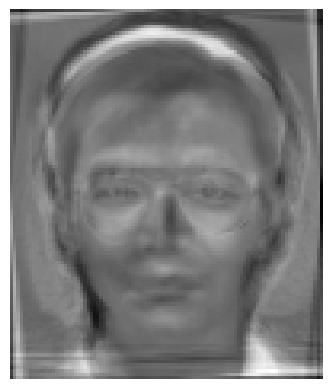

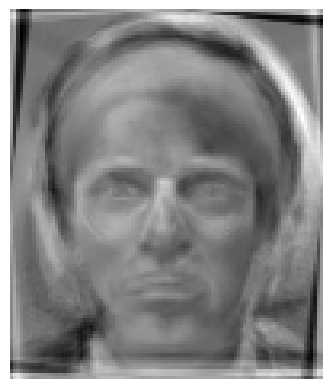

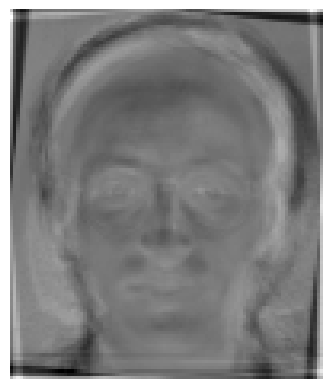

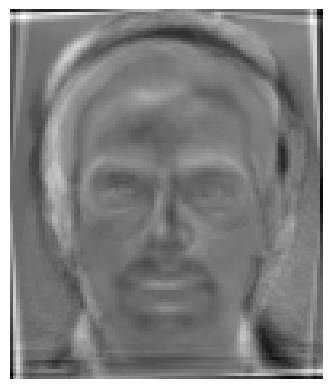

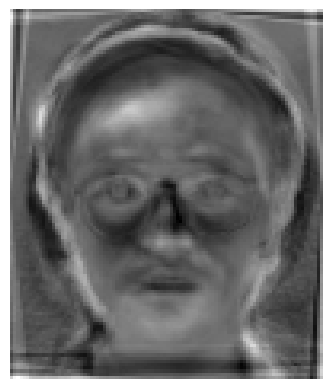

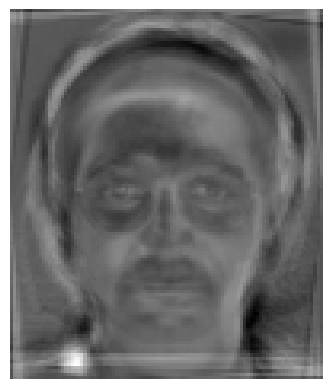

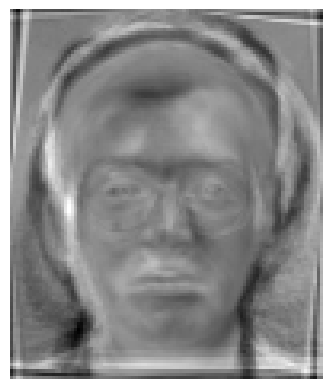

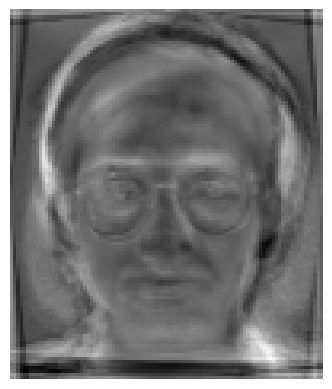

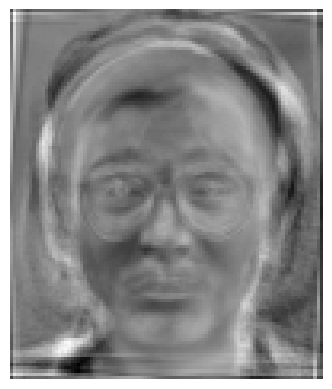

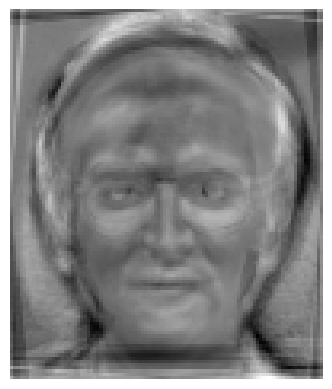

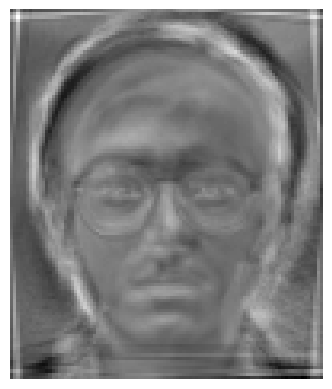

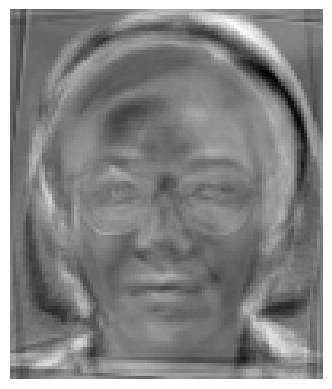

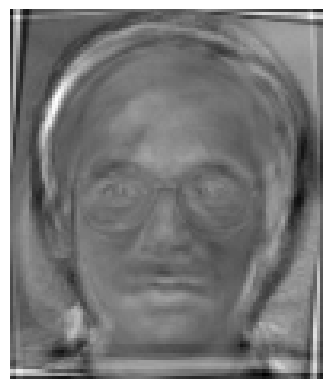

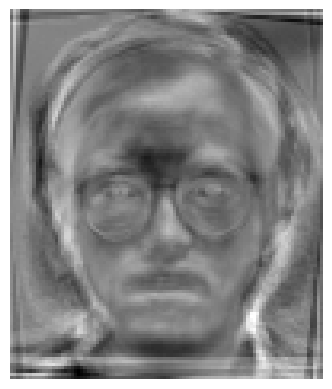

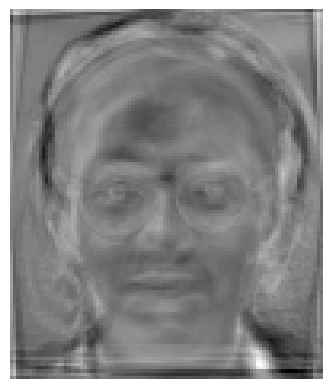

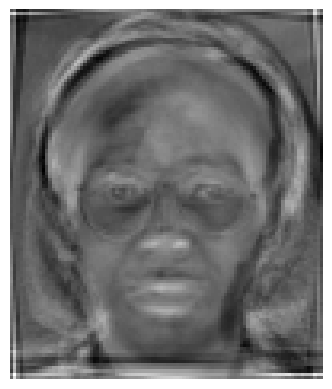

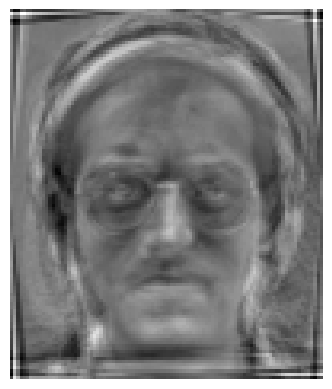

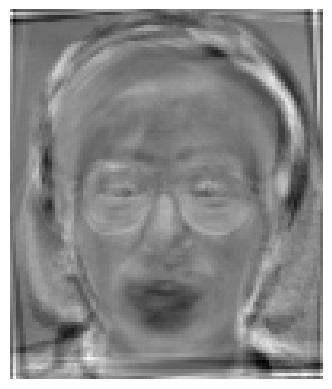

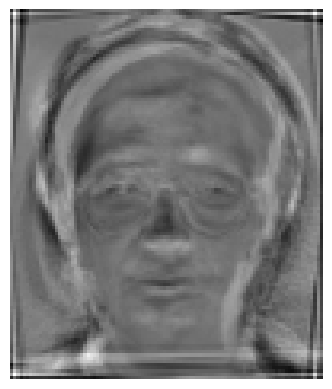

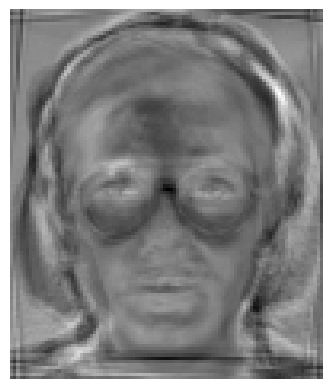

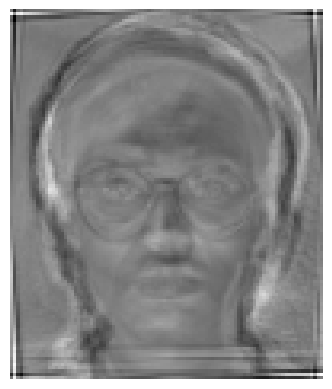

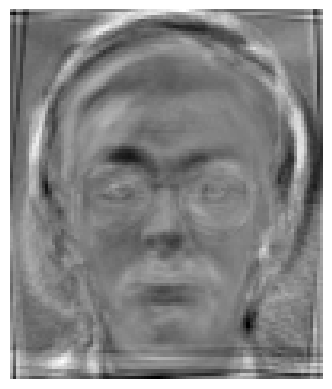

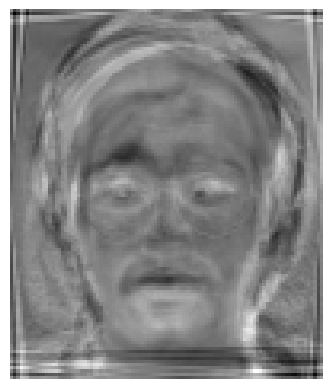

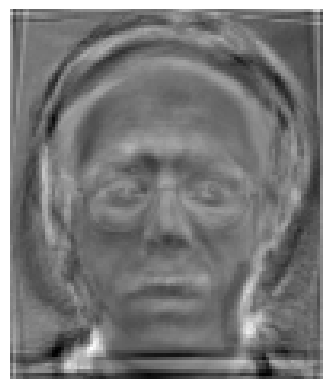

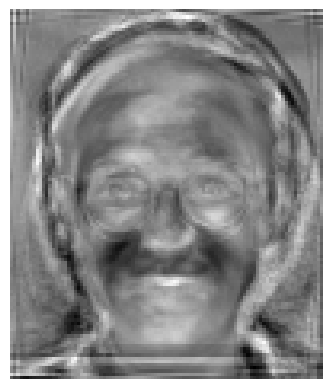

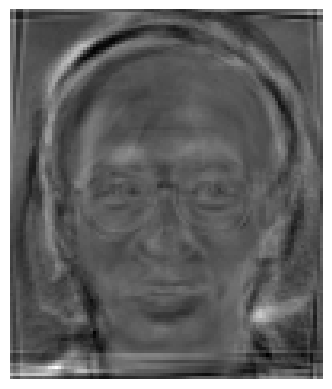

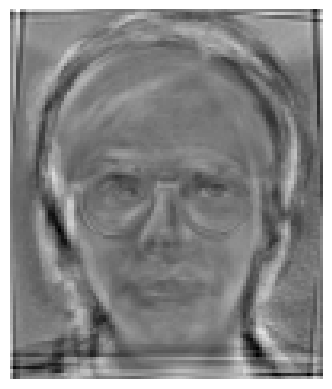

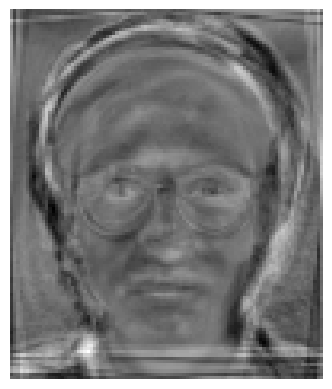

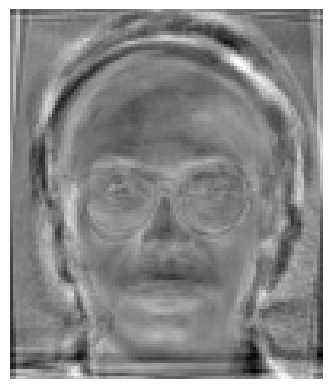

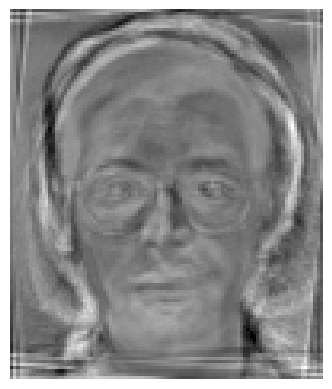

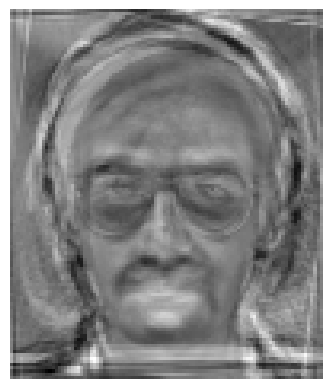

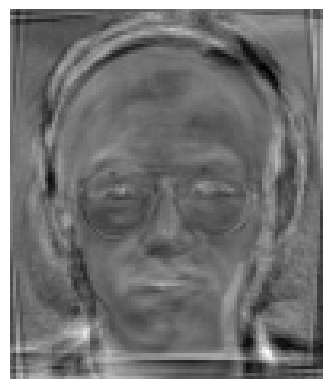

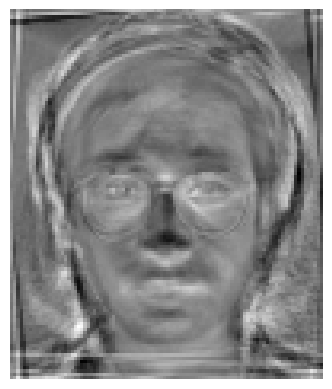

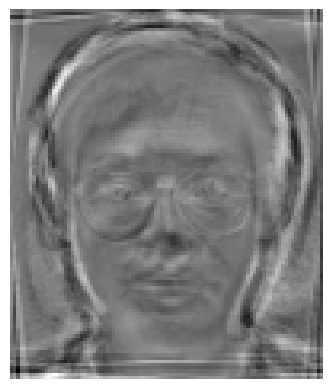

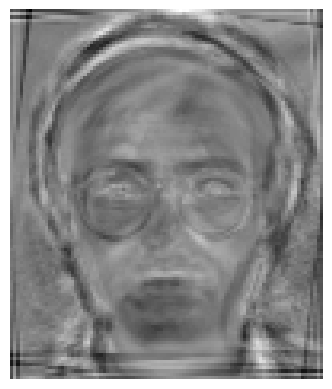

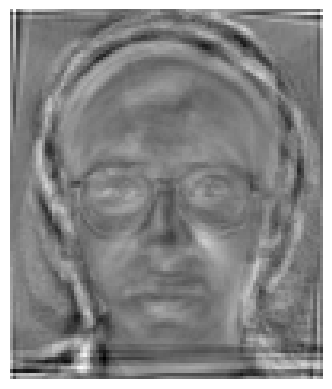

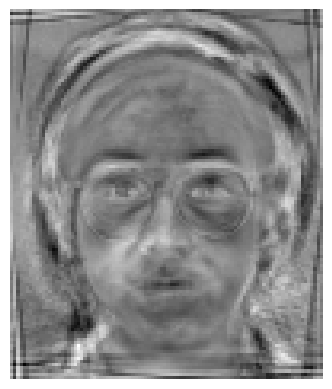

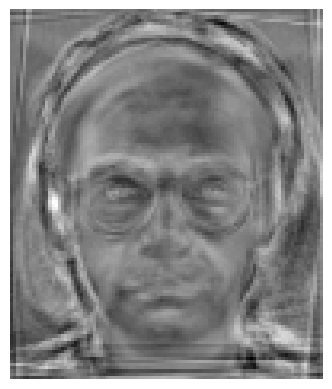

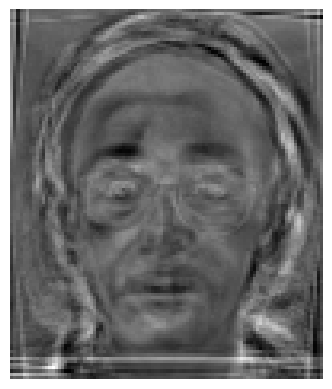

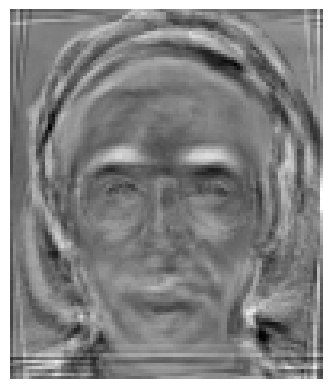

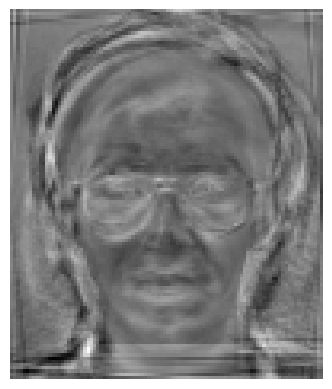

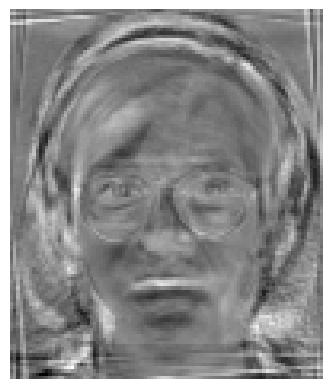

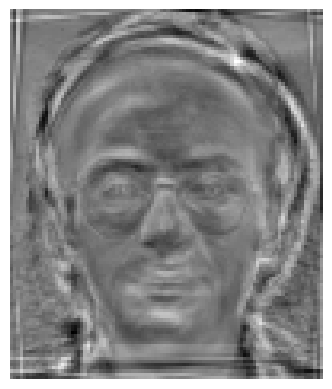

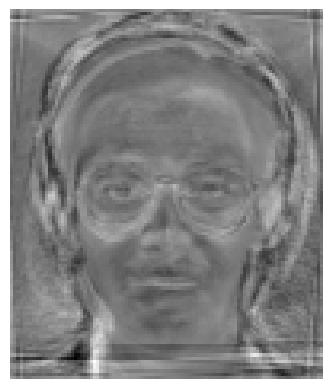

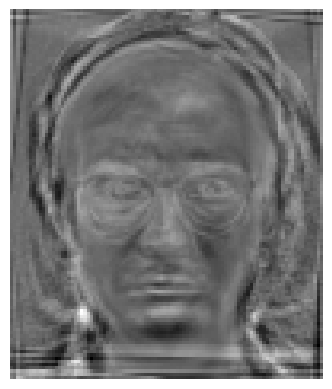

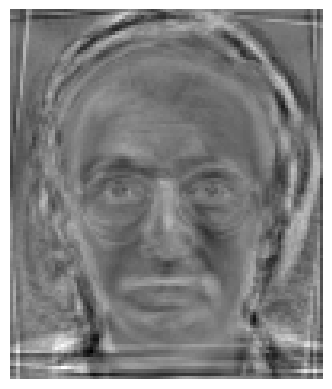

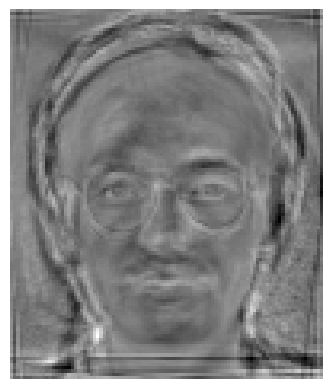

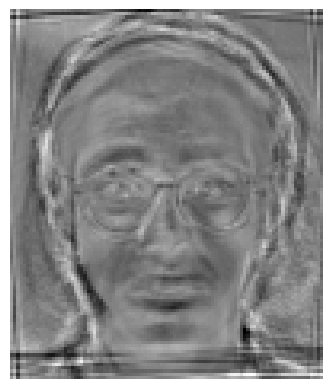

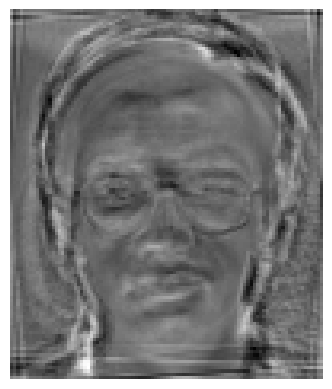

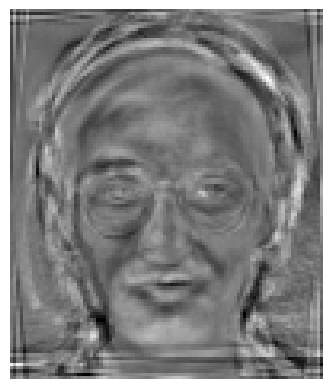

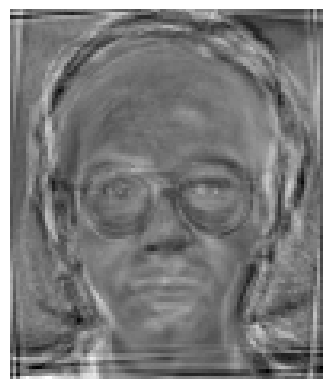

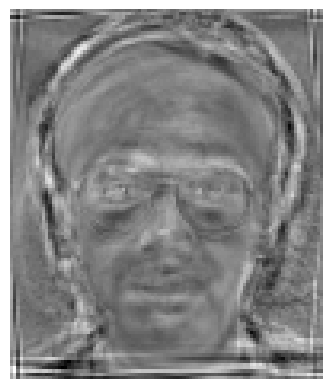

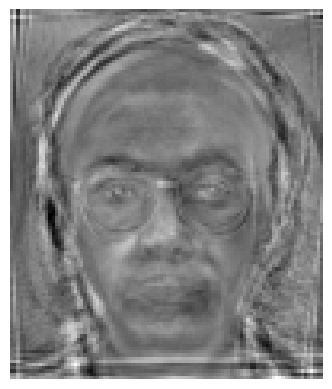

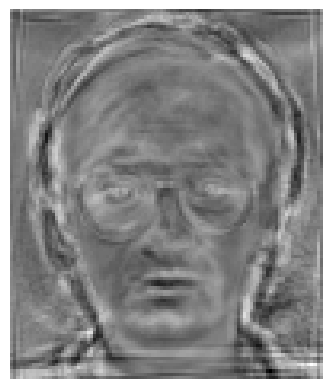

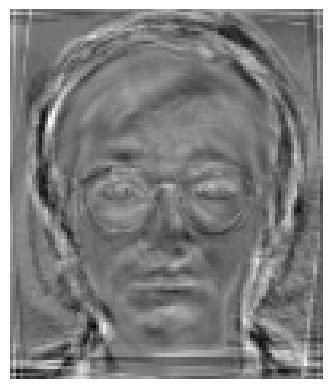

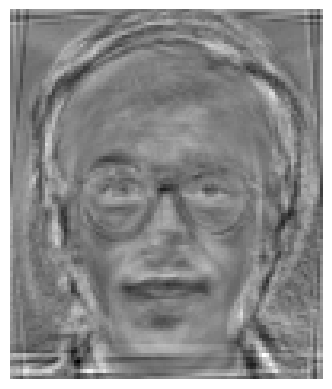

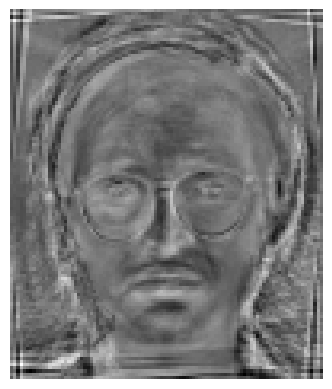

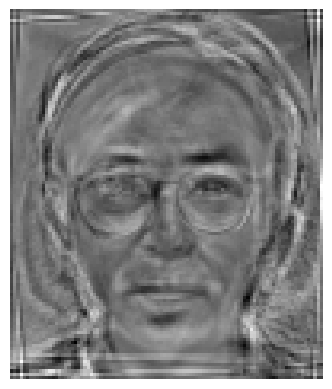

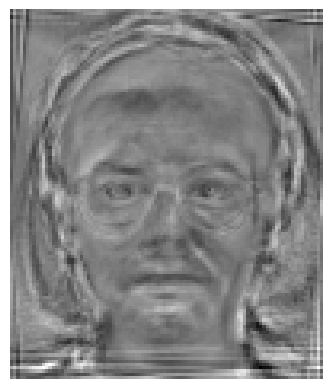

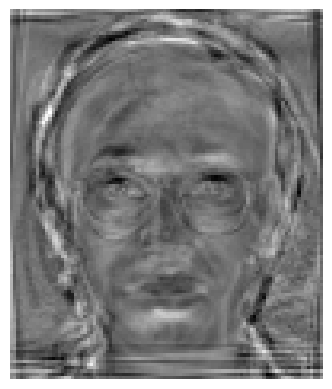

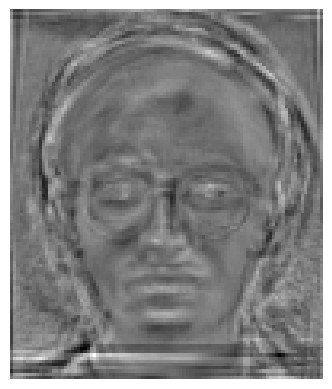

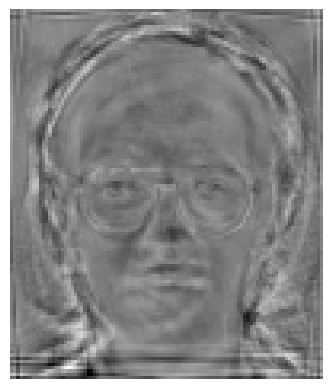

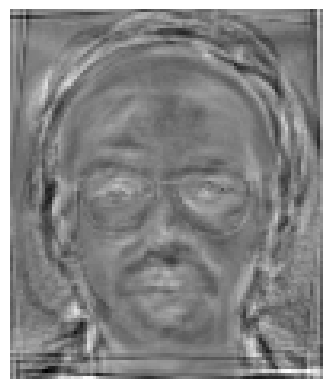

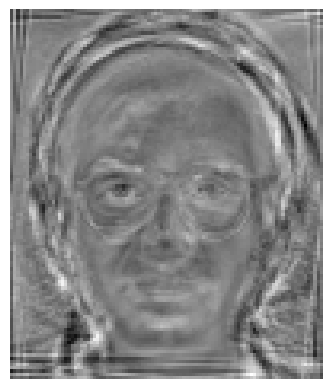

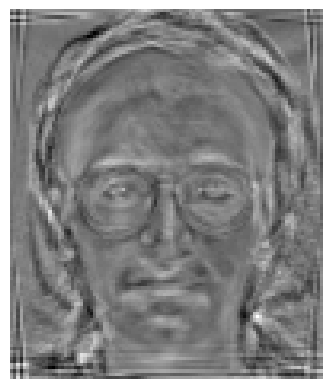

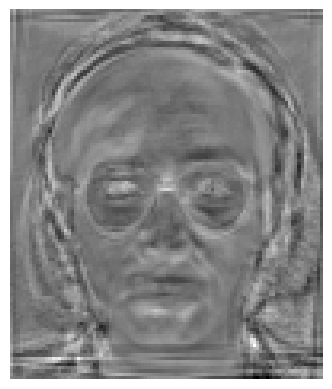

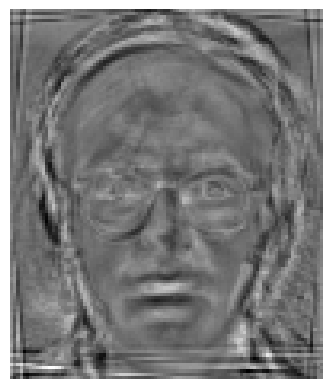

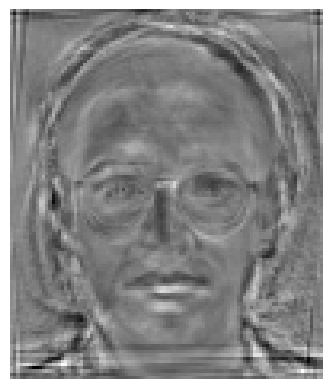

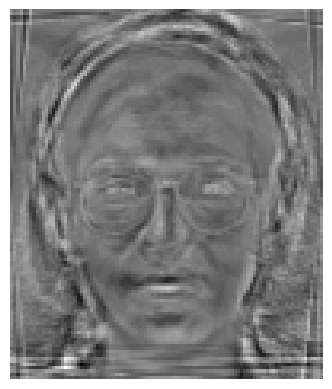

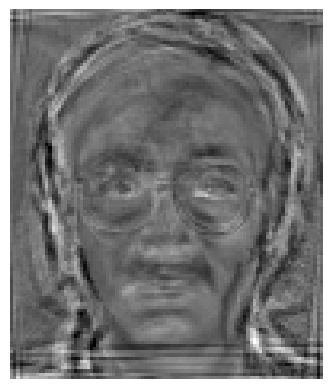

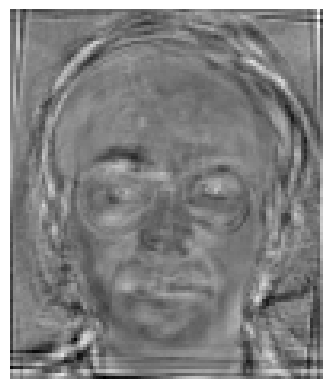

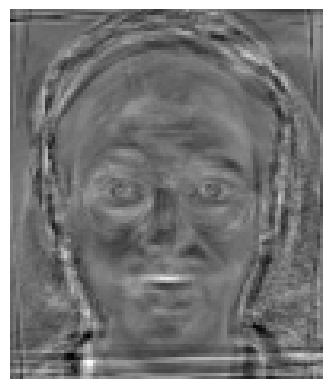

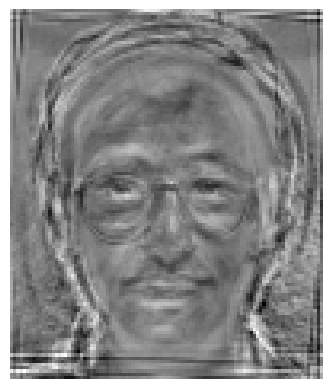

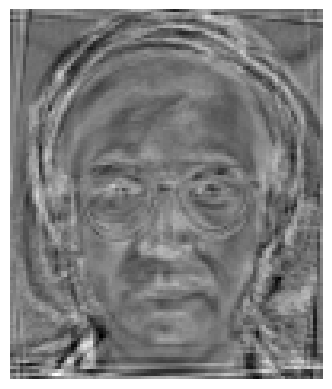

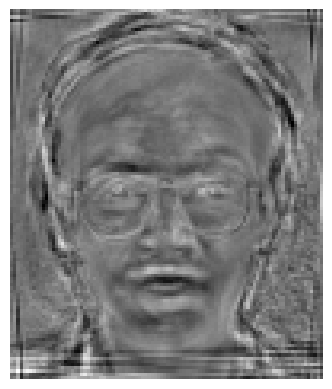

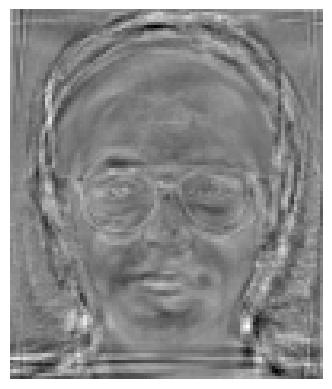

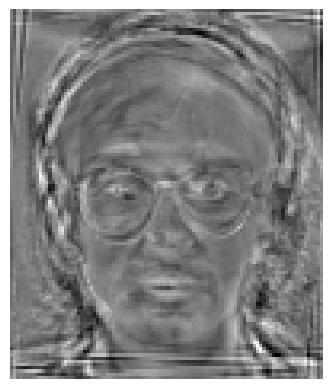

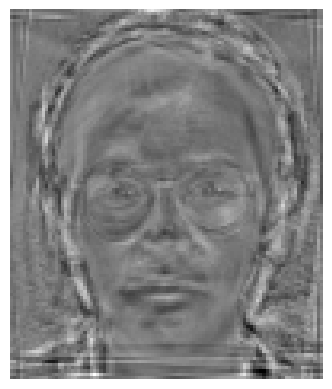

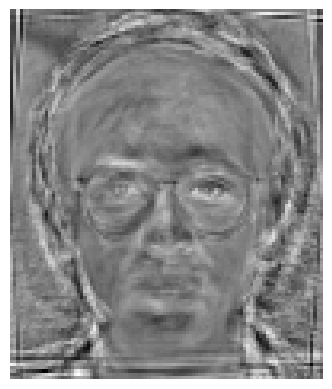

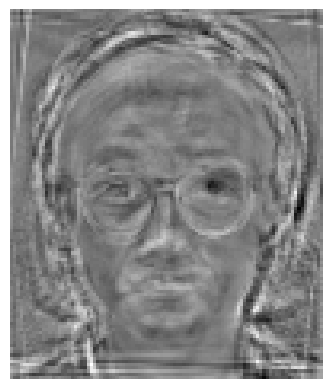

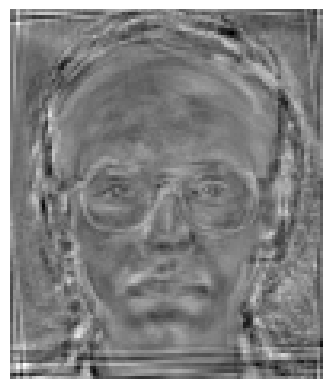

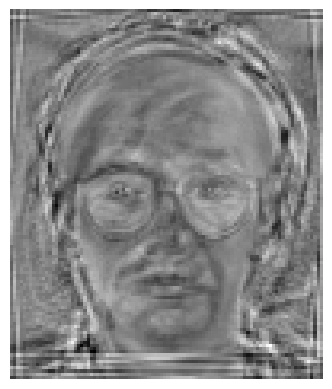

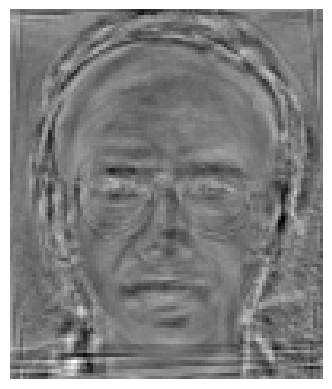

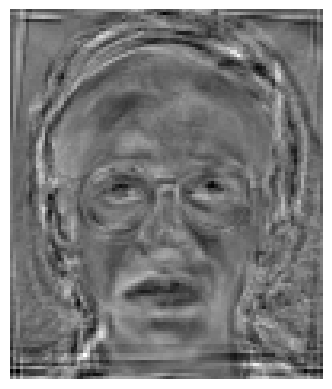

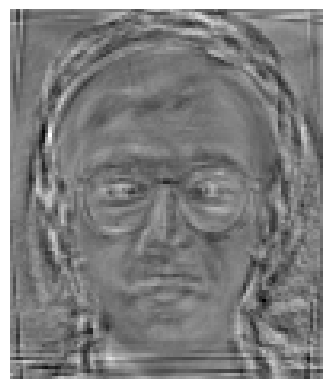

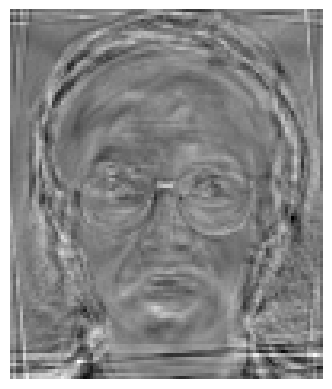

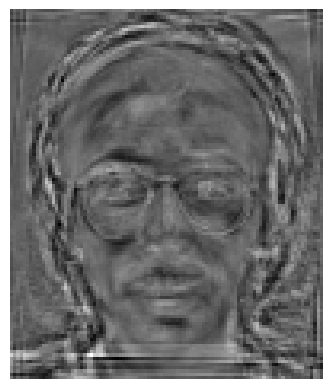

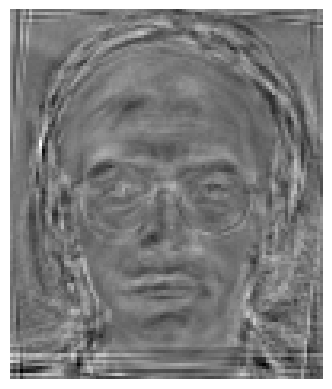

In [11]:
import matplotlib.pyplot as plt
for i in range(U.shape[1]):
    plt.axis('off')
    f1 = plt.imshow(U[:, i].reshape(116, 98), interpolation='nearest')
    f1.axes.get_xaxis().set_visible(False)
    f1.axes.get_yaxis().set_visible(False)
    plt.gray()
    fn = 'eigenface' + str(i).zfill(2) + 'png'
    plt.show()

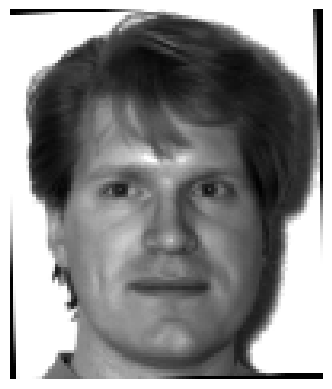

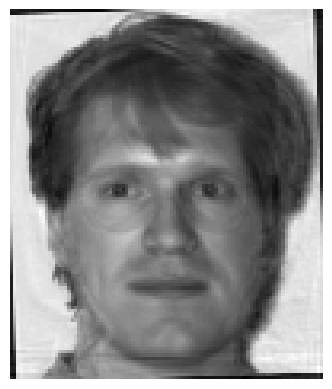

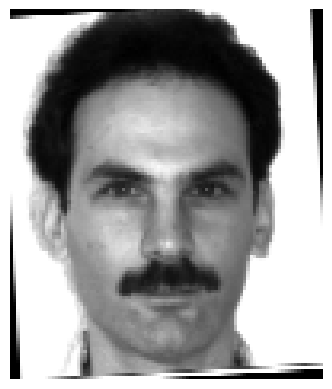

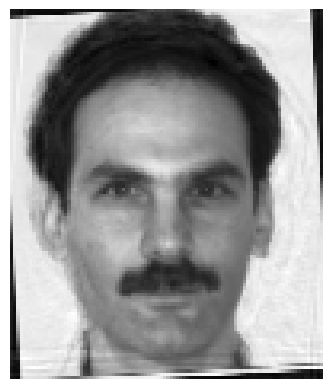

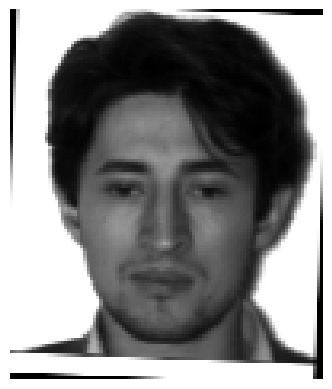

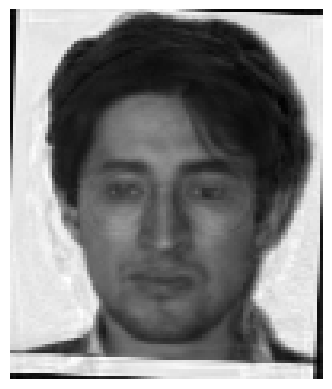

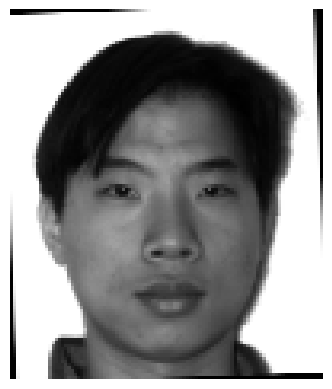

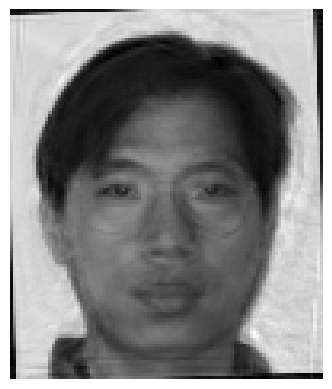

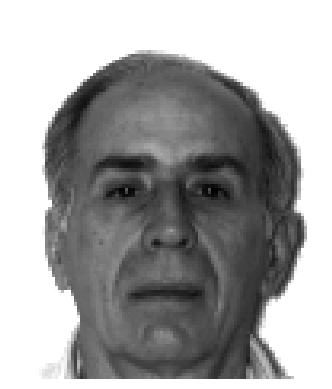

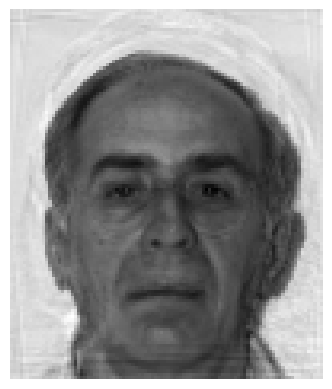

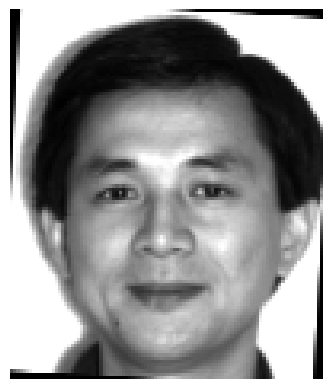

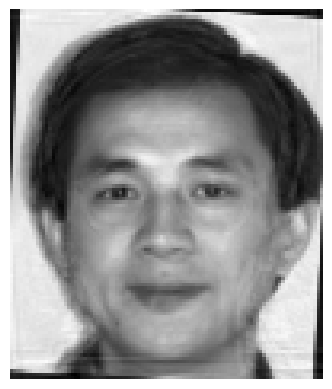

In [7]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio # Thay thế cho misc.imread
import numpy as np

# Giả sử các biến path, prefix, surfix, D, U, và pca đã được định nghĩa ở trên
# D = 11368 (116 * 98)

# See reconstruction of first 6 persons
for person_id in range(1, 7):
    for state in ['centerlight']:
        # 1. Đọc ảnh gốc
        fn = path + prefix + str(person_id).zfill(2) + '.' + state + surfix
        im = imageio.imread(fn)
        
        plt.axis('off')
        f1 = plt.imshow(im, interpolation='nearest')
        f1.axes.get_xaxis().set_visible(False)
        f1.axes.get_yaxis().set_visible(False)
        plt.gray()
        
        # Lưu ảnh gốc
        fn_ori = 'ori' + str(person_id).zfill(2) + '.png'
        plt.savefig(fn_ori, bbox_inches='tight', pad_inches=0)
        plt.show()
        
        # 2. Xử lý PCA (Reconstruction)
        # Reshape và trừ đi giá trị trung bình (mean centering)
        x = im.reshape(D, 1) - pca.mean_.reshape(D, 1)
        
        # Encode (Chiếu xuống không gian K chiều)
        z = U.T.dot(x)
        
        # Decode (Khôi phục lại không gian D chiều)
        x_tilde = U.dot(z) + pca.mean_.reshape(D, 1)
        
        # 3. Hiển thị ảnh sau khi khôi phục (Reconstructed Image)
        im_tilde = x_tilde.reshape(116, 98)
        plt.axis('off')
        f1 = plt.imshow(im_tilde, interpolation='nearest')
        f1.axes.get_xaxis().set_visible(False)
        f1.axes.get_yaxis().set_visible(False)
        plt.gray()
        
        # Lưu ảnh kết quả
        fn_res = 'res' + str(person_id).zfill(2) + '.png'
        plt.savefig(fn_res, bbox_inches='tight', pad_inches=0)
        plt.show()

In [8]:
import os

for person_id in range(1, 7):
    # Tạo lại tên file giống hệt lúc save
    fn_ori = 'ori' + str(person_id).zfill(2) + '.png'
    fn_res = 'res' + str(person_id).zfill(2) + '.png'
    
    # Kiểm tra nếu file tồn tại thì xóa
    if os.path.exists(fn_ori):
        os.remove(fn_ori)
    if os.path.exists(fn_res):
        os.remove(fn_res)

print("Đã xóa xong các file ảnh cụ thể.")

Đã xóa xong các file ảnh cụ thể.
